In [ ]:
from data.MNIST3d.voxelgrid import VoxelGrid

In [4]:
train_file = "./data/MNIST3d/train_point_clouds.h5"

In [13]:
import utils.subsampling
import importlib

importlib.reload(utils.subsampling)

point_clouds, labels = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=50)

In [17]:
import utils.utils
import importlib

importlib.reload(utils.utils)
noisy_clouds = utils.utils.add_gaussian_noise(point_clouds, sigma=0.005)

In [74]:
voxels = [VoxelGrid(cloud, x_y_z=[32, 32, 32]).vector for cloud in noisy_clouds]

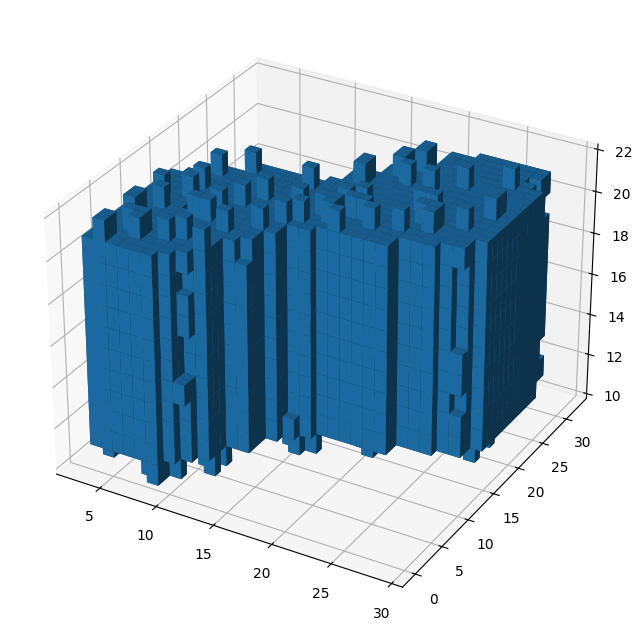

In [75]:
import matplotlib.pyplot as plt
import numpy as np

idx = np.where(labels == 8)[0][0]
V_bin = voxels[idx] > 0

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.voxels(V_bin)

plt.show()

In [68]:
import numpy as np

voxels_bin = np.array([
    (v > 0).astype(np.uint8)
    for v in voxels
])

print(voxels_bin.shape)

(500, 16, 16, 16)


HeightFiltration — это метод построения фильтрации для изображений, основанный на задании функции высоты на каждом вокселе. Формируется возрастающая последовательность множеств подуровней, включающих все точки изображения, для которых значение функции высоты не превышает заданного порога. При увеличении порога эти множества расширяются, задавая фильтрацию кубического комплекса.

In [69]:
from gtda.images import HeightFiltration

HF = HeightFiltration(
    direction=np.array([1, 1, 1]),
    n_jobs=-1
)

height_filtrations = HF.fit_transform(voxels_bin)

RadialFiltration основан на расстоянии от заданной центральной точки. Сначала выбирается центр, и каждому вокселю присваивается значение, равное его евклидову расстоянию до этого центра. После этого формируется последовательность подмножеств: сначала включаются точки, находящиеся ближе всего к центру, затем постепенно добавляются всё более удалённые. Изображение «растёт» в виде расширяющихся концентрических областей.

In [70]:
from gtda.images import RadialFiltration

HF = RadialFiltration(
    center=np.array([15, 15, 15])
)

height_filtrations = HF.fit_transform(voxels_bin)

В кубическом комплексе пространство строится из базовых элементов вида кубов. Каждый воксель рассматривается как единичный куб, а соседние элементы соединяются в соответствии с их смежностью, формируя структуру кубического комплекса.

In [71]:
from gtda.homology import CubicalPersistence

CP = CubicalPersistence(
    homology_dimensions=(0, 1, 2),
    n_jobs=-1
)

diagrams = CP.fit_transform(height_filtrations)

In [73]:
idx = np.where(labels == 8)[0][0]
CP.plot(diagrams, sample=idx)

In [226]:
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy, Scaler, Amplitude
from gtda.images import HeightFiltration, Binarizer

direction_list = [
    # [1, 1, 1],
    # [1, 1, 0],
    # [1, 1, -1],

    # [1, 0, 1],
    # [1, 0, 0],
    # [1, 0, -1],

    # [1, -1, 1],
    # [1, -1, 0],
    # [1, -1, -1],

    [0, 1, 1],
    # [0, 1, 0],
    # [0, 1, -1],

    # [0, 0, 1],
    # [0, 0, 0],
    # [0, 0, -1],

    # [0, -1, 1],
    # [0, -1, 0],
    # [0, -1, -1],

    # [-1, 1, 1],
    # [-1, 1, 0],
    # [-1, 1, -1],

    # [-1, 0, 1],
    # [-1, 0, 0],
    # [-1, 0, -1],

    # [-1, -1, 1],
    # [-1, -1, 0],
    # [-1, -1, -1]
]


# Creating a list of all filtration transformer, we will be applying
filtration_list = (
    [
        HeightFiltration(direction=np.array(direction), n_jobs=-1)
        for direction in direction_list
    ]
)

# Creating the diagram generation pipeline
diagram_steps = [
    [
        Binarizer(threshold=0.4, n_jobs=-1),
        filtration,
        CubicalPersistence(n_jobs=-1),
        Scaler(n_jobs=-1),
    ]
    for filtration in filtration_list
]

# Listing all metrics we want to use to extract diagram amplitudes
metric_list = [
    {"metric": "bottleneck", "metric_params": {}},
    {"metric": "wasserstein", "metric_params": {"p": 1}},
    {"metric": "wasserstein", "metric_params": {"p": 2}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 1, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 2, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 1, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 2, "n_bins": 100}},
    {"metric": "betti", "metric_params": {"p": 1, "n_bins": 100}},
    {"metric": "betti", "metric_params": {"p": 2, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 1.6, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 3.2, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 2, "sigma": 1.6, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 2, "sigma": 3.2, "n_bins": 100}},
]

#
feature_union = make_union(
    *[PersistenceEntropy(nan_fill_value=-1)]
    + [Amplitude(**metric, n_jobs=-1) for metric in metric_list],
    n_jobs=-1
)

tda_union = make_union(
    *[make_pipeline(*diagram_step, feature_union) for diagram_step in diagram_steps],
    n_jobs=-1
)

In [227]:
from sklearn import set_config
set_config(display='diagram')

tda_union

FeatureUnion(n_jobs=-1,
             transformer_list=[('pipeline',
                                Pipeline(steps=[('binarizer',
                                                 Binarizer(n_jobs=-1,
                                                           threshold=0.4)),
                                                ('heightfiltration',
                                                 HeightFiltration(direction=array([0, 1, 1]),
                                                                  n_jobs=-1)),
                                                ('cubicalpersistence',
                                                 CubicalPersistence(n_jobs=-1)),
                                                ('scaler', Scaler(n_jobs=-1)),
                                                ('featureunion',
                                                 FeatureUnion(n_jobs=-1,
                                                              transformer_list=[('persistenceentrop...
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 1,
                                                                                                          'sigma': 1.6},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-11',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 1,
                                                                                                          'sigma': 3.2},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-12',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 2,
                                                                                                          'sigma': 1.6},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-13',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 2,
                                                                                                          'sigma': 3.2},
                                                                                           n_jobs=-1))]))]))])

In [228]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    voxels,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [229]:
X_train_tda = tda_union.fit_transform(X_train)
X_train_tda.shape

(1600, 28)

In [230]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_jobs=-1)
rf.fit(X_train_tda, y_train)

X_test_tda = tda_union.transform(X_test)
rf.score(X_test_tda, y_test)

0.4

In [231]:
y_pred = rf.predict(X_test_tda)

In [232]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.33      0.33        40
           1       0.58      0.78      0.67        40
           2       0.35      0.33      0.34        40
           3       0.22      0.25      0.23        40
           4       0.39      0.38      0.38        40
           5       0.32      0.28      0.30        40
           6       0.71      0.60      0.65        40
           7       0.45      0.42      0.44        40
           8       0.27      0.30      0.29        40
           9       0.39      0.35      0.37        40

    accuracy                           0.40       400
   macro avg       0.40      0.40      0.40       400
weighted avg       0.40      0.40      0.40       400



In [241]:
from sklearn.pipeline import Pipeline

height_pipeline = Pipeline([
    ('binarizer', Binarizer(threshold=0.4)),
    ('filtration', HeightFiltration()),
    ('diagram', CubicalPersistence()),
    ('feature', PersistenceEntropy(nan_fill_value=-1)),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [242]:
from sklearn.model_selection import GridSearchCV

direction_list = [[0, 1, 0], [0, 0, 1], [0, 1, 1], [1, 1, 1]]

param_grid = {
    "filtration__direction": [np.array(direction) for direction in direction_list],
}

grid_search = GridSearchCV(
    estimator=height_pipeline, param_grid=param_grid, cv=3, n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('binarizer', Binarizer(threshold=0.4)),
                                       ('filtration', HeightFiltration()),
                                       ('diagram', CubicalPersistence()),
                                       ('feature',
                                        PersistenceEntropy(nan_fill_value=-1)),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'filtration__direction': [array([0, 1, 0]),
                                                   array([0, 0, 1]),
                                                   array([0, 1, 1]),
                                                   array([1, 1, 1])]})

In [245]:
grid_search.best_score_

0.19687983828844338